### Realtime Web Search with Langchain and Google's Gemini

In [1]:
# Get your free API key from: https://aistudio.google.com/

# pip install ddgs langchain langchain_google_genai -U

In [2]:
import os
from ddgs import DDGS

os.environ['USER_AGENT'] = 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'

from langchain_community.document_loaders import WebBaseLoader
from langchain_core.tools import tool

from langchain_google_genai import ChatGoogleGenerativeAI

from langchain.agents import create_agent
from langchain_core.prompts import ChatPromptTemplate

from dotenv import load_dotenv
load_dotenv()  # Load environment variables from .env file


True

In [3]:
from ddgs import DDGS

results = DDGS().text("python programming", max_results=5)
print(results)

[{'title': 'Python (programming language)', 'href': 'https://en.wikipedia.org/wiki/Python_(programming_language)', 'body': 'Python is a high-level, general-purpose programming language. Its design philosophy emphasizes code readability with the use of significant indentation. Python is dynamically type-checked and garbage-collected. It supports multiple programming paradigms, including structured (particularly procedural), object-oriented and functional programming.Guido van Rossum began working on Python in the late 1980s as a successor to the ABC programming language. Python 3.0, released in 2008, was a major revision and not completely backward-compatible with earlier versions. Beginning with Python 3.5, capabilities and keywords for typing were added to the language, allowing optional static typing. Currently only versions in the 3.x series are supported. Python has gained widespread use in the machine learning community. It is widely taught as an introductory programming language.

In [4]:
results[2]

{'title': 'Python Projects - Beginner to Advanced - GeeksforGeeks',
 'href': 'https://www.geeksforgeeks.org/python/python-projects-beginner-to-advanced/',
 'body': 'Turtle graphics in Python offer a fun way to learn programming by drawing shapes and patterns.'}

In [5]:
@tool
def web_search(query: str, num_results: int = 3) -> str:
    """
    Use this tool to perform a real-time web search and scrape the content of the top results.
    Useful for getting up-to-date news, documentation, or factual information.
    
    Args:
        query: The search query string.
        num_results: Number of results to search and scrape (default: 3).
                     Keep this low (3-5) to ensure speed.
    
    Returns:
        A formatted string containing titles, URLs, and the full page content of the search results.
    """
    print(f"🔎 Searching and Scraping for: '{query}'...")
    try:
        # 1. Perform the search using DuckDuckGo (Free, no API key required)
        # We use the 'text' backend for standard web results
        results = DDGS().text(query=query, max_results=num_results, region='us-en')
        
        if not results:
            return f"No results found for '{query}'"
        
        formatted_results = [f"--- Search Results for: '{query}' ---\n"]
        
        # 2. Iterate through results and Scrape content
        for i, result in enumerate(results, 1):
            title = result.get('title', 'No title')
            href = result.get('href', '')
            snippet = result.get('body', 'No description available')
            
            print(f"   Processing result {i}: {title[:30]}...")
            
            try:
                # Attempt to scrape the full page content
                loader = WebBaseLoader(href)
                # Set a timeout to prevent hanging on slow sites
                loader.requests_kwargs = {'timeout': 5} 
                docs = loader.load()
                
                # Clean up whitespace for the LLM
                page_content = "\n\n".join([doc.page_content for doc in docs])
                # Limit content length per page to avoid token limits (optional but recommended)
                page_content = page_content[:4000] 
                
                body = f"FULL PAGE CONTENT:\n{page_content}"
            except Exception as e:
                # Fallback to the search snippet if scraping fails
                print(f"   Failed to scrape {href}: {e}")
                body = f"SNIPPET (Scraping Failed):\n{snippet}"
            
            text = f"\nResult {i}:\nTitle: **{title}**\nURL: {href}\n{body}\n{'-'*50}"
            formatted_results.append(text)
        
        return "\n".join(formatted_results)
    
    except Exception as e:
        return f"Error performing search: {str(e)}"

In [6]:
result = web_search.invoke({'query': 'python programming', 'num_results': 3})
# print(result)

🔎 Searching and Scraping for: 'python programming'...


c:\Users\laxmi\anaconda3\envs\ml\Lib\site-packages\pydantic\v1\main.py:1054: UserWarning: LangSmith now uses UUID v7 for run and trace identifiers. This warning appears when passing custom IDs. Please use: from langsmith import uuid7
            id = uuid7()
Future versions will require UUID v7.
  input_data = validator(cls_, input_data)


   Processing result 1: Python (programming language)...
   Processing result 2: Welcome to Python.org...
   Processing result 3: Python Tutorial - W3Schools...


In [7]:
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)

In [8]:
tools = [web_search]

In [9]:
system_prompt = """You are a professional research agent with web_search capability. Follow these steps:

STEP 1: UNDERSTAND THE QUESTION
- Read the user's question carefully
- Identify the main topic and what they want to know

STEP 2: PLAN YOUR SEARCHES
- Think of 3-5 different search queries to cover the topic
- Consider different angles and perspectives

STEP 3: CONDUCT MULTIPLE SEARCHES
- Search #1: General overview search
- Search #2: Specific details search
- Search #3: Recent developments search
- Search #4-5: Additional targeted searches as needed

STEP 4: ANALYZE RESULTS
- Compare information across search results
- Identify key facts and patterns
- Note important URLs for reference

STEP 5: SYNTHESIZE FINDINGS
- Combine information from all searches
- Create a clear, comprehensive answer
- Include source URLs in your response

RULES:
- Always perform at least 3 searches
- Use different keywords for each search
- Focus on recent and reliable sources
- Cite sources with URLs
- Be thorough but concise

EXAMPLE:
User: "What are the latest AI developments?"

Your process:
1. web_search("latest AI developments 2025")
2. web_search("artificial intelligence breakthroughs recent")
3. web_search("new AI models released 2025")
4. Analyze all results
5. Write comprehensive answer with sources

Now research the user's question."""

In [10]:
agent = create_agent(model=llm, tools=tools, system_prompt=system_prompt)

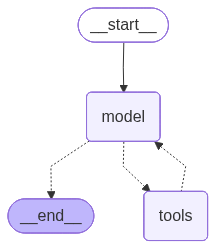

In [11]:
agent

In [13]:
from langchain_core.messages import HumanMessage

query = "What are the latest advancements in AI technology?"

result = agent.invoke({'messages': [HumanMessage(content=query)]})

🔎 Searching and Scraping for: 'latest AI advancements 2024'...
   Processing result 1: Top Data Infrastructure, Analy...
   Processing result 2: AI in 2024 : Advancements and ...
   Processing result 3: Latest AI Advancements 2024 | ...
🔎 Searching and Scraping for: 'breakthroughs in generative AI large language models computer vision 2024'...
   Processing result 1: AI and Machine Learning Advanc...
   Processing result 2: Enterprise AI Adoption Explode...
   Processing result 3: large language models Archives...
🔎 Searching and Scraping for: 'recent trends and future directions in AI technology'...
   Processing result 1: Future of AI in 2025 [Top Tren...
   Processing result 2: The Top Artificial Intelligenc...
   Processing result 3: AI Trends to Watch in 2025 & B...


In [14]:
result

{'messages': [HumanMessage(content='What are the latest advancements in AI technology?', additional_kwargs={}, response_metadata={}, id='d5949654-f7da-449e-b397-039d2aa35aa3'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'web_search', 'arguments': '{"query": "latest AI advancements 2024", "num_results": 3}'}, '__gemini_function_call_thought_signatures__': {'11dea72d-7d13-4c33-a710-b3db35187b38': 'CoIGAdHtim8A2psyk1Id8o5Yq2cn1Ck4vs/MFO0ulNuE/OnFjqxN6pHaCTJ9eYMvUZOFaFWwC5Y9tC7MW035caqhKfgQqAPSl6J6e4yUDdUcB1W/Kf9P4DE07y5AakHK3KJGQy/uKhZuM88pD2NDxOyRNfKN9XpIrsrDC0sRz9OkAVjFylsNOhA+767m/4H8rMmUfAj1UjRoYlq0PDr5N/44PBWrOe+MsT+Gixwqze9JcfXCB5sJT5hx7cY18WzdMkcn60TKu0F8U7bOtf676twern+m8uldcKRNuIFuW1k8k5A6gvM3RFVobyOx+f2p6x7ssCuJFtnkoyy7K1KCNNNX825c2v2oAhJenOv2r6E4lIJjjbZ9pu1SCRhXMt37FFIJuQqc9Qhj4F9iZFqwQxe2c326fBN3gjaLWqUCzvPPCnLIDjCz2H7Lhu0zVOBVUVHsn8s4ARPdsjeptteKXdIlYUPuvF7+PwWx7Fl36dZycVmht/LRe4Aa4YkrGPU0komaM91Vig0S6bJvgpRbuWATL2568un4nXmsU4so5hnrKSe8WnoN8rPTL6/kWfa

In [25]:
print(result['messages'][-1].content[0]['text'])

The field of Artificial Intelligence is experiencing rapid advancements, with significant breakthroughs and evolving trends shaping its future. Here's a summary of the latest developments:

**1. Generative AI and Large Language Models (LLMs):**
*   **Enhanced Capabilities:** LLMs continue to evolve, demonstrating remarkable abilities in generating human-like text, translating languages, summarizing complex information, and creating diverse content formats, including images, videos, music, and even code.
*   **Leading Models:** Prominent examples like Google's LaMDA and Gemini, NVIDIA's Megatron-Turing NLG, OpenAI’s GPT-4o, and Anthropic’s Claude 3 are pushing the boundaries of human-like communication and creative expression.
*   **Efficiency and Accessibility:** These models are becoming faster, more cost-effective to operate, and easier to integrate into existing systems and applications.

**2. Multimodal AI:**
*   **Integrated Understanding:** A key trend is the increasing ability o